# Unified Speech Emotion Recognition Benchmark

This notebook provides one reproducible pipeline for SAVEE + RAVDESS and compares:

- Classical baselines: RBF-SVM and Extra Trees
- Deep spectrogram models: Mel-CNN, CNN-BiLSTM with attention, Mel Transformer
- Pretrained speech model: Wav2Vec2

The workflow fixes the main validity problems found in the original notebooks:

1. Speakers—not individual utterances—are separated across train, validation and test sets.
2. File discovery is restricted to the two configured dataset folders.
3. Duplicate removal and a manifest fingerprint prevent stale caches.
4. Feature normalization, arousal statistics and calibration use training/validation data only.
5. The test set is never used for model selection.
6. Stress is explicitly reported as a theory-derived proxy, not clinical ground truth.
7. All models use the same split and metric definitions.

Run the notebook from top to bottom in Google Colab. A GPU is strongly recommended for the self-supervised models.


## Experimental contract

- **Primary metric:** speaker-independent macro F1.
- **Model selection:** validation macro F1 only.
- **Final evaluation:** one evaluation on held-out test speakers.
- **Calibration:** temperature is fitted on validation logits and evaluated on test logits.
- **Stress output:** a deterministic proxy derived from predicted emotion and acoustic arousal. It is not independently labelled stress and must not be described as stress-detection accuracy.
- **Reproducibility:** the split manifest, feature cache fingerprint, package versions and random seed are saved.


In [1]:
# Install dependencies in Colab. Restart the runtime if Colab requests it.
%pip install -q librosa soundfile scikit-learn seaborn transformers accelerate joblib


In [2]:
# Imports and configuration
import copy
import gc
import hashlib
import json
import os
import platform
import random
import sys
import time
import warnings
from pathlib import Path

import joblib
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import soundfile as sf
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.base import clone
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoFeatureExtractor, AutoModel

warnings.filterwarnings('default')
sns.set_theme(style='whitegrid')

SEED = 42
SAMPLE_RATE = 16_000
DURATION_SECONDS = 4.0
N_SAMPLES = int(SAMPLE_RATE * DURATION_SECONDS)
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512
N_MFCC = 40
NUM_CLASSES = 7

EMOTIONS = [
    'anger', 'disgust', 'fear', 'happiness',
    'neutral', 'sadness', 'surprise',
]
EMOTION_TO_ID = {name: i for i, name in enumerate(EMOTIONS)}
ID_TO_EMOTION = {i: name for name, i in EMOTION_TO_ID.items()}

VERIFY_CONTENT_HASHES = True
REBUILD_FEATURE_CACHE = False
RUN_GROUPED_CV_BASELINE = True

MEL_MODELS_TO_RUN = [
    'mel_cnn',
    'cnn_bilstm',
    'mel_transformer',
]

WAV2VEC2_MODEL_NAME = 'facebook/wav2vec2-base'
SSL_UNFREEZE_LAST_N_LAYERS = 2

MEL_EPOCHS = 60
MEL_PATIENCE = 10
MEL_BATCH_SIZE = 32
SSL_EPOCHS = 25
SSL_PATIENCE = 6
SSL_BATCH_SIZE = 6

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP_ENABLED = DEVICE.type == 'cuda'

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)

seed_everything()

print('Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
print('Python:', platform.python_version())
print('PyTorch:', torch.__version__)
print('librosa:', librosa.__version__)
print('scikit-learn:', sklearn.__version__)


Device: cuda
GPU: Tesla T4
Python: 3.13.15
PyTorch: 2.11.0+cu128
librosa: 0.11.0
scikit-learn: 1.6.1


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
# Mount Drive and configure exact dataset roots
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT = Path('/content/drive/MyDrive')
else:
    # Change this when running outside Colab.
    DRIVE_ROOT = Path.cwd()

SAVEE_ROOT = DRIVE_ROOT / 'SAVEE DATASET'
RAVDESS_ROOT = DRIVE_ROOT / 'RAVDESS DATASET'
ARTIFACT_ROOT = DRIVE_ROOT / 'C2_Research_Unified'
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

assert SAVEE_ROOT.exists(), f'SAVEE folder not found: {SAVEE_ROOT}'
assert RAVDESS_ROOT.exists(), f'RAVDESS folder not found: {RAVDESS_ROOT}'

print('SAVEE:', SAVEE_ROOT)
print('RAVDESS:', RAVDESS_ROOT)
print('Artifacts:', ARTIFACT_ROOT)


Mounted at /content/drive
SAVEE: /content/drive/MyDrive/SAVEE DATASET
RAVDESS: /content/drive/MyDrive/RAVDESS DATASET
Artifacts: /content/drive/MyDrive/C2_Research_Unified


In [4]:
# Build a strict, auditable dataset manifest
SAVEE_MAP = {
    'a': 'anger',
    'd': 'disgust',
    'f': 'fear',
    'h': 'happiness',
    'n': 'neutral',
    'sa': 'sadness',
    'su': 'surprise',
}
RAVDESS_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happiness',
    '04': 'sadness',
    '05': 'anger',
    '06': 'fear',
    '07': 'disgust',
    '08': 'surprise',
}

def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, 'rb') as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()

def parse_savee(path):
    stem = path.stem
    if '_' not in stem:
        return None
    speaker, remainder = stem.split('_', 1)
    code_name = ''.join(ch for ch in remainder if ch.isalpha()).lower()
    emotion = SAVEE_MAP.get(code_name)
    if emotion is None:
        return None
    return {
        'filepath': str(path),
        'filename': path.name,
        'dataset': 'SAVEE',
        'speaker': f'SAVEE_{speaker.upper()}',
        'emotion': emotion,
        'label': EMOTION_TO_ID[emotion],
    }

def parse_ravdess(path):
    parts = path.stem.split('-')
    if len(parts) != 7 or parts[0] != '03' or parts[1] != '01':
        return None
    emotion = RAVDESS_MAP.get(parts[2])
    if emotion is None or emotion == 'calm':
        return None
    actor = parts[6]
    return {
        'filepath': str(path),
        'filename': path.name,
        'dataset': 'RAVDESS',
        'speaker': f'RAVDESS_{actor}',
        'emotion': emotion,
        'label': EMOTION_TO_ID[emotion],
    }

savee_files = sorted(SAVEE_ROOT.rglob('*.wav'))
ravdess_files = sorted(RAVDESS_ROOT.rglob('*.wav'))

records = []
for path in savee_files:
    row = parse_savee(path)
    if row is not None:
        records.append(row)
for path in ravdess_files:
    row = parse_ravdess(path)
    if row is not None:
        records.append(row)

manifest = pd.DataFrame(records).sort_values(
    ['dataset', 'speaker', 'filename', 'filepath']
).reset_index(drop=True)

if manifest.empty:
    raise RuntimeError('No usable SAVEE/RAVDESS files were found.')

# Lightweight corruption and duration checks before splitting.
quality_rows = []
for idx, row in tqdm(manifest.iterrows(), total=len(manifest), desc='Audio headers'):
    try:
        info = sf.info(row.filepath)
        duration = float(info.frames / info.samplerate)
        ok = info.frames > 0 and info.samplerate > 0 and duration >= 0.5
        error = '' if ok else 'empty, invalid, or shorter than 0.5 seconds'
    except Exception as exc:
        duration = np.nan
        ok = False
        error = str(exc)
    quality_rows.append((idx, ok, duration, error))

quality = pd.DataFrame(
    quality_rows, columns=['row_index', 'ok', 'duration_seconds', 'error']
).set_index('row_index')
manifest['duration_seconds'] = quality['duration_seconds']
bad_rows = quality.index[~quality.ok].tolist()
if bad_rows:
    quality.loc[bad_rows].to_csv(ARTIFACT_ROOT / 'rejected_audio.csv')
    manifest = manifest.drop(index=bad_rows).reset_index(drop=True)

if VERIFY_CONTENT_HASHES:
    manifest['sha256'] = [
        sha256_file(path)
        for path in tqdm(manifest.filepath, desc='SHA-256 duplicate check')
    ]
    conflicts = manifest.groupby('sha256').emotion.nunique()
    conflicts = conflicts[conflicts > 1]
    if len(conflicts):
        raise RuntimeError('Identical audio has conflicting emotion labels.')
    before = len(manifest)
    manifest = manifest.drop_duplicates('sha256', keep='first').reset_index(drop=True)
    print('Exact duplicates removed:', before - len(manifest))
else:
    manifest['sha256'] = [
        hashlib.sha256(
            f'{row.dataset}|{row.filename}|{Path(row.filepath).stat().st_size}'.encode()
        ).hexdigest()
        for row in manifest.itertuples()
    ]

manifest['sample_id'] = manifest.sha256.str[:16]

assert manifest.sample_id.is_unique
assert set(manifest.emotion) == set(EMOTIONS)

print()
print('Clean samples:', len(manifest))
print('Speakers:', manifest.speaker.nunique())
print(pd.crosstab(manifest.dataset, manifest.emotion))
print()
print(manifest.groupby('dataset').speaker.nunique())

manifest.to_csv(ARTIFACT_ROOT / 'manifest_clean.csv', index=False)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Audio headers:   0%|          | 0/1729 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


SHA-256 duplicate check:   0%|          | 0/1729 [00:00<?, ?it/s]

Exact duplicates removed: 2

Clean samples: 1727
Speakers: 28
emotion  anger  disgust  fear  happiness  neutral  sadness  surprise
dataset                                                             
RAVDESS    192      192   192        191       96      192       192
SAVEE       60       60    60         60      120       60        60

dataset
RAVDESS    24
SAVEE       4
Name: speaker, dtype: int64


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
# Deterministic speaker-disjoint 70/15/15 split
#
# Candidate group splits are scored for sample count, emotion balance and
# corpus balance. Labels are never mixed across a speaker boundary.

def normalized_counts(series, categories):
    return (
        series.value_counts(normalize=True)
        .reindex(categories, fill_value=0.0)
        .to_numpy(dtype=float)
    )

def choose_group_holdout(frame, n_holdout_groups, target_fraction, seed):
    label_ids = list(range(NUM_CLASSES))
    corpora = ['SAVEE', 'RAVDESS']
    target_label_dist = normalized_counts(frame.label, label_ids)
    target_corpus_dist = normalized_counts(frame.dataset, corpora)

    splitter = GroupShuffleSplit(
        n_splits=2000,
        test_size=n_holdout_groups,
        random_state=seed,
    )

    best_score = float('inf')
    best_indices = None

    for _, local_holdout in splitter.split(frame, frame.label, frame.speaker):
        candidate = frame.iloc[local_holdout]
        label_dist = normalized_counts(candidate.label, label_ids)
        corpus_dist = normalized_counts(candidate.dataset, corpora)

        size_penalty = abs(len(candidate) / len(frame) - target_fraction)
        label_penalty = np.abs(label_dist - target_label_dist).mean()
        corpus_penalty = np.abs(corpus_dist - target_corpus_dist).mean()
        missing_penalty = 10.0 if candidate.label.nunique() < NUM_CLASSES else 0.0
        corpus_missing_penalty = 2.0 if candidate.dataset.nunique() < 2 else 0.0

        score = (
            3.0 * size_penalty
            + 2.0 * label_penalty
            + corpus_penalty
            + missing_penalty
            + corpus_missing_penalty
        )
        if score < best_score:
            best_score = score
            best_indices = candidate.index.to_numpy()

    if best_indices is None:
        raise RuntimeError('Could not construct a valid grouped holdout.')
    return best_indices

all_speakers = manifest.speaker.nunique()
test_group_count = max(2, round(all_speakers * 0.15))
test_idx = choose_group_holdout(
    manifest,
    n_holdout_groups=test_group_count,
    target_fraction=0.15,
    seed=SEED,
)

remaining = manifest.drop(index=test_idx)
val_group_count = max(2, round(all_speakers * 0.15))
val_idx = choose_group_holdout(
    remaining,
    n_holdout_groups=val_group_count,
    target_fraction=0.15 / 0.85,
    seed=SEED + 1,
)

train_idx = manifest.index.difference(np.concatenate([val_idx, test_idx])).to_numpy()
val_idx = np.asarray(val_idx)
test_idx = np.asarray(test_idx)

manifest['split'] = 'train'
manifest.loc[val_idx, 'split'] = 'validation'
manifest.loc[test_idx, 'split'] = 'test'

train_speakers = set(manifest.loc[train_idx, 'speaker'])
val_speakers = set(manifest.loc[val_idx, 'speaker'])
test_speakers = set(manifest.loc[test_idx, 'speaker'])

assert train_speakers.isdisjoint(val_speakers)
assert train_speakers.isdisjoint(test_speakers)
assert val_speakers.isdisjoint(test_speakers)
assert set(train_idx) | set(val_idx) | set(test_idx) == set(manifest.index)

for split_name in ['train', 'validation', 'test']:
    part = manifest[manifest.split == split_name]
    print(
        f'{split_name:10s}: {len(part):4d} samples, '
        f'{part.speaker.nunique():2d} speakers, '
        f'{sorted(part.speaker.unique())}'
    )
    print(pd.crosstab(part.dataset, part.emotion))
    print()

manifest.to_csv(ARTIFACT_ROOT / 'manifest_with_split.csv', index=False)

split_payload = {
    'seed': SEED,
    'strategy': 'speaker-disjoint candidate search',
    'train_sample_ids': manifest.loc[train_idx, 'sample_id'].tolist(),
    'validation_sample_ids': manifest.loc[val_idx, 'sample_id'].tolist(),
    'test_sample_ids': manifest.loc[test_idx, 'sample_id'].tolist(),
    'train_speakers': sorted(train_speakers),
    'validation_speakers': sorted(val_speakers),
    'test_speakers': sorted(test_speakers),
}
with open(ARTIFACT_ROOT / 'split.json', 'w') as handle:
    json.dump(split_payload, handle, indent=2)


train     : 1176 samples, 20 speakers, ['RAVDESS_01', 'RAVDESS_02', 'RAVDESS_03', 'RAVDESS_05', 'RAVDESS_08', 'RAVDESS_11', 'RAVDESS_12', 'RAVDESS_13', 'RAVDESS_14', 'RAVDESS_15', 'RAVDESS_16', 'RAVDESS_17', 'RAVDESS_18', 'RAVDESS_19', 'RAVDESS_20', 'RAVDESS_21', 'RAVDESS_23', 'RAVDESS_24', 'SAVEE_DC', 'SAVEE_KL']
emotion  anger  disgust  fear  happiness  neutral  sadness  surprise
dataset                                                             
RAVDESS    144      144   144        144       72      144       144
SAVEE       30       30    30         30       60       30        30

validation:  275 samples,  4 speakers, ['RAVDESS_04', 'RAVDESS_06', 'RAVDESS_07', 'SAVEE_JK']
emotion  anger  disgust  fear  happiness  neutral  sadness  surprise
dataset                                                             
RAVDESS     24       24    24         23       12       24        24
SAVEE       15       15    15         15       30       15        15

test      :  276 samples,  4 speaker

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Leakage-safe preprocessing

Important changes from the original notebooks:

- Silence is trimmed before cropping or padding.
- Cropping is centred and deterministic for evaluation.
- Energy is measured before amplitude normalization and before zero padding.
- Log-mel values are normalized using training speakers only.
- Raw audio remains float32 for Wav2Vec2.
- Valid waveform lengths are retained so Wav2Vec2 can mask padding.
- The cache filename contains a manifest/configuration fingerprint.


In [6]:
# Extract one shared feature cache for every model
FEATURE_CONFIG = {
    'sample_rate': SAMPLE_RATE,
    'duration_seconds': DURATION_SECONDS,
    'n_mels': N_MELS,
    'n_fft': N_FFT,
    'hop_length': HOP_LENGTH,
    'n_mfcc': N_MFCC,
    'pitch_method': 'pyin_80_500_hz',
    'trim_top_db': 30,
}

fingerprint_source = (
    '|'.join(manifest.sample_id.tolist())
    + json.dumps(FEATURE_CONFIG, sort_keys=True)
)
FEATURE_FINGERPRINT = hashlib.sha256(
    fingerprint_source.encode()
).hexdigest()[:12]
FEATURE_CACHE = ARTIFACT_ROOT / f'features_{FEATURE_FINGERPRINT}.npz'

def summarize_frames(values):
    values = np.asarray(values, dtype=np.float32)
    return np.concatenate([
        np.nanmean(values, axis=1),
        np.nanstd(values, axis=1),
    ]).astype(np.float32)

def fixed_length_audio(audio):
    audio = np.asarray(audio, dtype=np.float32)
    if len(audio) > N_SAMPLES:
        start = (len(audio) - N_SAMPLES) // 2
        fixed = audio[start:start + N_SAMPLES]
        valid_length = N_SAMPLES
    else:
        valid_length = len(audio)
        fixed = np.pad(audio, (0, N_SAMPLES - len(audio)))
    return fixed.astype(np.float32), int(valid_length)

def extract_one_file(filepath):
    audio, _ = librosa.load(filepath, sr=SAMPLE_RATE, mono=True)
    audio, _ = librosa.effects.trim(audio, top_db=30)

    if len(audio) < int(0.5 * SAMPLE_RATE):
        raise ValueError('Audio became shorter than 0.5 seconds after trimming.')

    analysis_audio = audio.astype(np.float32)
    waveform, valid_length = fixed_length_audio(analysis_audio)

    mel_power = librosa.feature.melspectrogram(
        y=waveform,
        sr=SAMPLE_RATE,
        n_mels=N_MELS,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        fmin=20,
        fmax=SAMPLE_RATE // 2,
        power=2.0,
    )
    log_mel = librosa.power_to_db(
        mel_power,
        ref=1.0,
        top_db=80,
    ).astype(np.float32)

    mfcc = librosa.feature.mfcc(
        y=waveform,
        sr=SAMPLE_RATE,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
    )
    chroma = librosa.feature.chroma_stft(
        y=waveform,
        sr=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
    )
    centroid = librosa.feature.spectral_centroid(
        y=waveform, sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    bandwidth = librosa.feature.spectral_bandwidth(
        y=waveform, sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    rolloff = librosa.feature.spectral_rolloff(
        y=waveform, sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    zcr = librosa.feature.zero_crossing_rate(
        waveform, frame_length=N_FFT, hop_length=HOP_LENGTH
    )

    f0, voiced, _ = librosa.pyin(
        analysis_audio,
        fmin=80,
        fmax=500,
        sr=SAMPLE_RATE,
        hop_length=HOP_LENGTH,
    )
    valid_pitch = f0[voiced & np.isfinite(f0)] if voiced is not None else np.array([])
    pitch_mean = float(np.mean(valid_pitch)) if len(valid_pitch) else np.nan
    pitch_std = float(np.std(valid_pitch)) if len(valid_pitch) else np.nan

    rms = librosa.feature.rms(
        y=analysis_audio,
        frame_length=N_FFT,
        hop_length=HOP_LENGTH,
    )[0]
    rms_db = 20.0 * np.log10(np.maximum(rms, 1e-8))
    energy_db_mean = float(np.mean(rms_db))
    energy_db_std = float(np.std(rms_db))

    prosody = np.array([
        pitch_mean,
        pitch_std,
        energy_db_mean,
        energy_db_std,
    ], dtype=np.float32)

    engineered = np.concatenate([
        summarize_frames(mfcc),
        summarize_frames(chroma),
        summarize_frames(centroid),
        summarize_frames(bandwidth),
        summarize_frames(rolloff),
        summarize_frames(zcr),
        np.nan_to_num(prosody, nan=0.0),
    ]).astype(np.float32)

    return {
        'waveform': waveform,
        'valid_length': valid_length,
        'log_mel': log_mel,
        'engineered': engineered,
        'prosody': prosody,
    }

if FEATURE_CACHE.exists() and not REBUILD_FEATURE_CACHE:
    cache = np.load(FEATURE_CACHE, allow_pickle=False)
    cached_ids = cache['sample_ids'].astype(str)
    if not np.array_equal(cached_ids, manifest.sample_id.to_numpy()):
        raise RuntimeError('Feature cache order does not match the current manifest.')
    waveforms = cache['waveforms'].astype(np.float32)
    valid_lengths = cache['valid_lengths'].astype(np.int64)
    log_mels = cache['log_mels'].astype(np.float32)
    engineered_features = cache['engineered_features'].astype(np.float32)
    prosody_features = cache['prosody_features'].astype(np.float32)
    print('Loaded cache:', FEATURE_CACHE)
else:
    extracted = []
    for row in tqdm(manifest.itertuples(), total=len(manifest), desc='Feature extraction'):
        try:
            extracted.append(extract_one_file(row.filepath))
        except Exception as exc:
            raise RuntimeError(f'Feature extraction failed for {row.filepath}: {exc}') from exc

    waveforms = np.stack([x['waveform'] for x in extracted]).astype(np.float32)
    valid_lengths = np.array([x['valid_length'] for x in extracted], dtype=np.int64)
    log_mels = np.stack([x['log_mel'] for x in extracted]).astype(np.float32)
    engineered_features = np.stack(
        [x['engineered'] for x in extracted]
    ).astype(np.float32)
    prosody_features = np.stack([x['prosody'] for x in extracted]).astype(np.float32)

    np.savez_compressed(
        FEATURE_CACHE,
        sample_ids=manifest.sample_id.to_numpy(dtype='U16'),
        waveforms=waveforms,
        valid_lengths=valid_lengths,
        log_mels=log_mels,
        engineered_features=engineered_features,
        prosody_features=prosody_features,
    )
    print('Saved cache:', FEATURE_CACHE)

labels = manifest.label.to_numpy(dtype=np.int64)

print('Waveforms:', waveforms.shape, waveforms.dtype)
print('Valid lengths:', valid_lengths.shape)
print('Log-mels:', log_mels.shape)
print('Engineered:', engineered_features.shape)
print('Prosody:', prosody_features.shape)


Feature extraction:   0%|          | 0/1727 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/audioread/rawread.py:16: DeprecationWarning: aifc was removed in Python 3.13. Please be aware that you are currently NOT using standard 'aifc', but instead a separately installed 'standard-aifc'.
  import aifc
/usr/local/lib/python3.13/dist-packages/audioread/rawread.py:19: DeprecationWarning: sunau was removed in Python 3.13. Please be aware that you are currently NOT using standard 'sunau', but instead a separately installed 'standard-sunau'.
  import sunau
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future versi

Saved cache: /content/drive/MyDrive/C2_Research_Unified/features_00c0d4718cd5.npz
Waveforms: (1727, 64000) float32
Valid lengths: (1727,)
Log-mels: (1727, 128, 126)
Engineered: (1727, 116)
Prosody: (1727, 4)


In [7]:
# Fit every normalization and arousal-proxy statistic on training speakers only
mel_mean = log_mels[train_idx].mean(axis=(0, 2), keepdims=True)
mel_std = log_mels[train_idx].std(axis=(0, 2), keepdims=True) + 1e-6

def robust_location_scale(train_values):
    train_values = np.asarray(train_values, dtype=float)
    train_values = train_values[np.isfinite(train_values)]
    median = float(np.median(train_values))
    q25, q75 = np.percentile(train_values, [25, 75])
    scale = float(max(q75 - q25, 1e-6))
    return median, scale

pitch_center, pitch_scale = robust_location_scale(prosody_features[train_idx, 0])
energy_center, energy_scale = robust_location_scale(prosody_features[train_idx, 2])

pitch_z = (prosody_features[:, 0] - pitch_center) / pitch_scale
energy_z = (prosody_features[:, 2] - energy_center) / energy_scale
pitch_z = np.nan_to_num(pitch_z, nan=0.0, posinf=0.0, neginf=0.0)
energy_z = np.nan_to_num(energy_z, nan=0.0, posinf=0.0, neginf=0.0)

# This is an acoustic arousal proxy—not a validated arousal label.
arousal_score = 0.5 * pitch_z + 0.5 * energy_z
arousal_threshold = float(np.quantile(arousal_score[train_idx], 0.60))
arousal_proxy = np.where(arousal_score > arousal_threshold, 'HIGH', 'LOW')

manifest['arousal_score'] = arousal_score
manifest['arousal_proxy'] = arousal_proxy

print('Training-only mel mean/std shapes:', mel_mean.shape, mel_std.shape)
print('Training-only arousal threshold:', arousal_threshold)
print(pd.crosstab(
    manifest.loc[test_idx, 'emotion'],
    manifest.loc[test_idx, 'arousal_proxy'],
    normalize='index',
).round(3))

np.savez(
    ARTIFACT_ROOT / 'preprocessing_statistics.npz',
    mel_mean=mel_mean,
    mel_std=mel_std,
    pitch_center=pitch_center,
    pitch_scale=pitch_scale,
    energy_center=energy_center,
    energy_scale=energy_scale,
    arousal_threshold=arousal_threshold,
)
manifest.to_csv(ARTIFACT_ROOT / 'manifest_with_features_and_split.csv', index=False)


Training-only mel mean/std shapes: (1, 128, 1) (1, 128, 1)
Training-only arousal threshold: 0.24767792224884033
arousal_proxy   HIGH    LOW
emotion                    
anger          0.769  0.231
disgust        0.487  0.513
fear           0.641  0.359
happiness      0.769  0.231
neutral        0.738  0.262
sadness        0.410  0.590
surprise       0.744  0.256


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [8]:
# Shared evaluation, calibration and diagnostics
results = []
prediction_store = {}
validation_scores = {}
model_registry = {}

def expected_calibration_error(probs, y_true, n_bins=15):
    probs = np.asarray(probs)
    y_true = np.asarray(y_true)
    confidence = probs.max(axis=1)
    prediction = probs.argmax(axis=1)
    correct = prediction == y_true
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for lower, upper in zip(edges[:-1], edges[1:]):
        mask = (confidence > lower) & (confidence <= upper)
        if mask.any():
            ece += mask.mean() * abs(correct[mask].mean() - confidence[mask].mean())
    return float(ece)

def multiclass_brier_score(probs, y_true):
    targets = np.eye(NUM_CLASSES)[np.asarray(y_true)]
    return float(np.mean(np.sum((np.asarray(probs) - targets) ** 2, axis=1)))

def group_bootstrap_interval(y_true, y_pred, groups, metric, repeats=2000, seed=SEED):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    groups = np.asarray(groups)
    unique_groups = np.unique(groups)
    rng = np.random.default_rng(seed)
    scores = []
    for _ in range(repeats):
        sampled_groups = rng.choice(
            unique_groups, size=len(unique_groups), replace=True
        )
        sampled_indices = np.concatenate([
            np.flatnonzero(groups == group) for group in sampled_groups
        ])
        scores.append(metric(y_true[sampled_indices], y_pred[sampled_indices]))
    return tuple(np.quantile(scores, [0.025, 0.975]))

def metric_record(name, y_true, probs, groups):
    probs = np.asarray(probs, dtype=float)
    y_true = np.asarray(y_true, dtype=int)
    y_pred = probs.argmax(axis=1)

    try:
        auc = roc_auc_score(
            y_true, probs, multi_class='ovr', average='macro'
        )
    except ValueError:
        auc = np.nan

    accuracy_ci = group_bootstrap_interval(
        y_true, y_pred, groups, accuracy_score
    )
    macro_f1_ci = group_bootstrap_interval(
        y_true,
        y_pred,
        groups,
        lambda a, b: f1_score(a, b, average='macro', zero_division=0),
    )

    return {
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_precision': precision_score(
            y_true, y_pred, average='macro', zero_division=0
        ),
        'macro_recall': recall_score(
            y_true, y_pred, average='macro', zero_division=0
        ),
        'macro_f1': f1_score(
            y_true, y_pred, average='macro', zero_division=0
        ),
        'weighted_f1': f1_score(
            y_true, y_pred, average='weighted', zero_division=0
        ),
        'macro_roc_auc_ovr': auc,
        'nll': log_loss(y_true, probs, labels=np.arange(NUM_CLASSES)),
        'brier': multiclass_brier_score(probs, y_true),
        'ece_15_bins': expected_calibration_error(probs, y_true),
        'accuracy_ci_low': accuracy_ci[0],
        'accuracy_ci_high': accuracy_ci[1],
        'macro_f1_ci_low': macro_f1_ci[0],
        'macro_f1_ci_high': macro_f1_ci[1],
    }

def save_diagnostics(name, y_true, probs):
    safe_name = name.replace('/', '_').replace(' ', '_')
    y_pred = np.asarray(probs).argmax(axis=1)

    report = classification_report(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
        target_names=EMOTIONS,
        output_dict=True,
        zero_division=0,
    )
    pd.DataFrame(report).T.to_csv(
        ARTIFACT_ROOT / f'{safe_name}_classification_report.csv'
    )

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))
    cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=axes[0]
    )
    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
        xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=axes[1]
    )
    for axis in axes:
        axis.set_xlabel('Predicted')
        axis.set_ylabel('True')
        axis.tick_params(axis='x', rotation=45)
    axes[0].set_title(f'{name}: counts')
    axes[1].set_title(f'{name}: row-normalized')
    plt.tight_layout()
    plt.savefig(
        ARTIFACT_ROOT / f'{safe_name}_confusion_matrix.png',
        dpi=150,
        bbox_inches='tight',
    )
    plt.show()

class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_temperature = nn.Parameter(torch.zeros(1))

    @property
    def temperature(self):
        return self.log_temperature.exp()

    def forward(self, logits):
        return logits / self.temperature.clamp_min(1e-4)

def fit_temperature(validation_logits, validation_labels):
    validation_logits = torch.as_tensor(validation_logits, dtype=torch.float32)
    validation_labels = torch.as_tensor(validation_labels, dtype=torch.long)
    scaler = TemperatureScaler()
    optimizer = torch.optim.LBFGS(
        scaler.parameters(), lr=0.05, max_iter=100
    )

    def closure():
        optimizer.zero_grad()
        loss = F.cross_entropy(scaler(validation_logits), validation_labels)
        loss.backward()
        return loss

    optimizer.step(closure)
    return scaler.eval()

def calibrated_probabilities(logits, scaler):
    logits = torch.as_tensor(logits, dtype=torch.float32)
    with torch.no_grad():
        return F.softmax(scaler(logits), dim=1).numpy()


## Classical baselines

These models are inexpensive and important for research credibility. A complex neural model should outperform them under exactly the same speaker-independent split.


Training rbf_svm


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


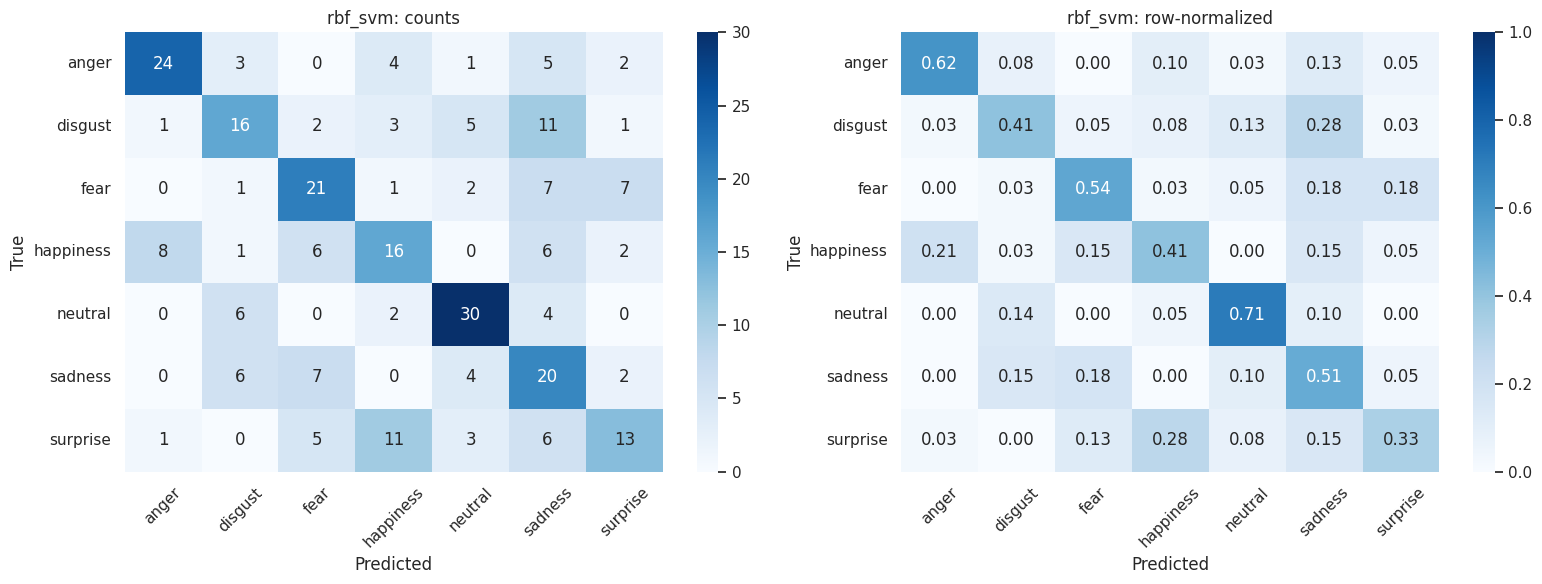

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Training extra_trees


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

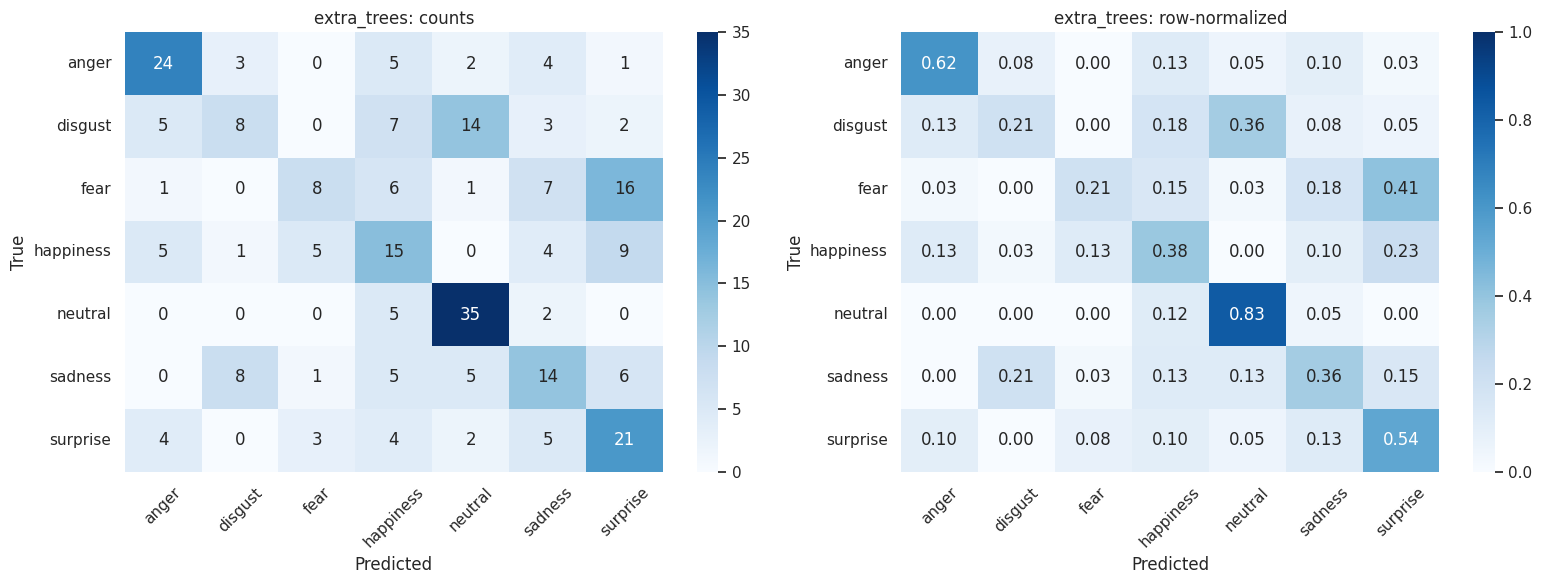

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,model,validation_macro_f1,accuracy,macro_f1,macro_roc_auc_ovr,ece_15_bins
0,rbf_svm,0.357693,0.507246,0.505684,0.828664,0.094292
1,extra_trees,0.400206,0.452899,0.431425,0.828681,0.116758


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
# Train classical baselines
X_train = engineered_features[train_idx]
X_val = engineered_features[val_idx]
X_test = engineered_features[test_idx]
y_train = labels[train_idx]
y_val = labels[val_idx]
y_test = labels[test_idx]
test_groups = manifest.loc[test_idx, 'speaker'].to_numpy()

classical_models = {
    'rbf_svm': Pipeline([
        ('scale', StandardScaler()),
        ('model', SVC(
            C=10.0,
            gamma='scale',
            probability=True,
            class_weight='balanced',
            random_state=SEED,
        )),
    ]),
    'extra_trees': ExtraTreesClassifier(
        n_estimators=600,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        n_jobs=-1,
        random_state=SEED,
    ),
}

for name, estimator in classical_models.items():
    print('Training', name)
    estimator.fit(X_train, y_train)
    val_probs = estimator.predict_proba(X_val)
    test_probs = estimator.predict_proba(X_test)

    val_f1 = f1_score(
        y_val, val_probs.argmax(axis=1), average='macro', zero_division=0
    )
    validation_scores[name] = float(val_f1)
    prediction_store[name] = test_probs
    model_registry[name] = {
        'kind': 'classical',
        'model': estimator,
    }

    row = metric_record(name, y_test, test_probs, test_groups)
    row['validation_macro_f1'] = val_f1
    results.append(row)
    save_diagnostics(name, y_test, test_probs)
    joblib.dump(estimator, ARTIFACT_ROOT / f'{name}.joblib')

pd.DataFrame(results).sort_values(
    'macro_f1', ascending=False
)[[
    'model', 'validation_macro_f1', 'accuracy', 'macro_f1',
    'macro_roc_auc_ovr', 'ece_15_bins'
]]


## Deep spectrogram models

All three models receive the same training-normalized log-mel spectrogram. SpecAugment is applied only to training batches. Acoustic arousal features are deliberately not fused into the emotion classifier by default, avoiding an unfair speaker/gender shortcut.


In [10]:
# Mel datasets and deterministic loaders
class MelDataset(Dataset):
    def __init__(self, indices, training=False):
        self.indices = np.asarray(indices)
        self.training = training

    def __len__(self):
        return len(self.indices)

    def _spec_augment(self, mel):
        mel = mel.clone()
        if torch.rand(1).item() < 0.5:
            time_width = int(torch.randint(0, 21, (1,)).item())
            if time_width:
                start = int(torch.randint(0, mel.shape[1] - time_width + 1, (1,)).item())
                mel[:, start:start + time_width] = 0.0
        if torch.rand(1).item() < 0.5:
            freq_width = int(torch.randint(0, 13, (1,)).item())
            if freq_width:
                start = int(torch.randint(0, mel.shape[0] - freq_width + 1, (1,)).item())
                mel[start:start + freq_width, :] = 0.0
        return mel

    def __getitem__(self, item):
        idx = int(self.indices[item])
        mel = (log_mels[idx] - mel_mean[0]) / mel_std[0]
        mel = torch.tensor(mel, dtype=torch.float32)
        if self.training:
            mel = self._spec_augment(mel)
        return {
            'mel': mel,
            'labels': torch.tensor(labels[idx], dtype=torch.long),
        }

def make_mel_loaders():
    common = {
        'batch_size': MEL_BATCH_SIZE,
        'num_workers': 2,
        'pin_memory': DEVICE.type == 'cuda',
        'worker_init_fn': seed_worker,
    }
    train_loader = DataLoader(
        MelDataset(train_idx, training=True),
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
        **common,
    )
    val_loader = DataLoader(
        MelDataset(val_idx, training=False), shuffle=False, **common
    )
    test_loader = DataLoader(
        MelDataset(test_idx, training=False), shuffle=False, **common
    )
    return train_loader, val_loader, test_loader


In [11]:
# Mel model definitions
class MelCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.10),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.15),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.30),
            nn.Linear(128, num_classes),
        )

    def forward(self, mel):
        return self.classifier(self.features(mel.unsqueeze(1)))

class CNNBiLSTMAttention(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 48, 3, padding=1),
            nn.BatchNorm2d(48),
            nn.GELU(),
            nn.MaxPool2d((2, 2)),

            nn.Conv2d(48, 96, 3, padding=1),
            nn.BatchNorm2d(96),
            nn.GELU(),
            nn.MaxPool2d((2, 2)),

            nn.Conv2d(96, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.MaxPool2d((2, 1)),
        )
        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.25,
        )
        self.attention = nn.Sequential(
            nn.Linear(256, 96),
            nn.Tanh(),
            nn.Linear(96, 1),
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(256),
            nn.Dropout(0.30),
            nn.Linear(256, num_classes),
        )

    def forward(self, mel):
        x = self.cnn(mel.unsqueeze(1))
        x = x.mean(dim=2).transpose(1, 2)
        x, _ = self.lstm(x)
        weights = torch.softmax(self.attention(x), dim=1)
        pooled = torch.sum(weights * x, dim=1)
        return self.classifier(pooled)

class SinusoidalPositionEncoding(nn.Module):
    def __init__(self, d_model=128, max_length=512):
        super().__init__()
        position = torch.arange(max_length).unsqueeze(1).float()
        divisor = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-np.log(10000.0) / d_model)
        )
        encoding = torch.zeros(max_length, d_model)
        encoding[:, 0::2] = torch.sin(position * divisor)
        encoding[:, 1::2] = torch.cos(position * divisor)
        self.register_buffer('encoding', encoding.unsqueeze(0))

    def forward(self, x):
        return x + self.encoding[:, :x.shape[1]]

class MelTransformer(nn.Module):
    def __init__(
        self,
        num_classes=NUM_CLASSES,
        d_model=128,
        heads=4,
        layers=3,
        dropout=0.20,
    ):
        super().__init__()
        self.projection = nn.Sequential(
            nn.Linear(N_MELS, d_model),
            nn.LayerNorm(d_model),
        )
        self.position = SinusoidalPositionEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=layers)
        self.attention_pool = nn.Linear(d_model, 1)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, mel):
        x = mel.transpose(1, 2)
        x = self.position(self.projection(x))
        x = self.encoder(x)
        weights = torch.softmax(self.attention_pool(x), dim=1)
        pooled = torch.sum(weights * x, dim=1)
        return self.classifier(pooled)

MEL_MODEL_BUILDERS = {
    'mel_cnn': MelCNN,
    'cnn_bilstm': CNNBiLSTMAttention,
    'mel_transformer': MelTransformer,
}

for name, builder in MEL_MODEL_BUILDERS.items():
    model = builder()
    parameters = sum(p.numel() for p in model.parameters())
    print(f'{name:20s}: {parameters:,} parameters')


mel_cnn             : 94,023 parameters
cnn_bilstm          : 839,848 parameters
mel_transformer     : 612,872 parameters


/tmp/ipykernel_1312/2856066209.py:118: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=layers)


In [12]:
# Shared PyTorch training utilities
def split_batch(batch):
    labels_batch = batch['labels'].to(DEVICE, non_blocking=True)
    features = {
        key: value.to(DEVICE, non_blocking=True)
        for key, value in batch.items()
        if key != 'labels'
    }
    return features, labels_batch

@torch.no_grad()
def collect_logits(model, loader):
    model.eval()
    logits_all = []
    labels_all = []
    for batch in loader:
        features, labels_batch = split_batch(batch)
        logits = model(**features)
        logits_all.append(logits.detach().cpu())
        labels_all.append(labels_batch.detach().cpu())
    return (
        torch.cat(logits_all).numpy(),
        torch.cat(labels_all).numpy(),
    )

def train_torch_model(
    name,
    model,
    train_loader,
    val_loader,
    epochs,
    patience,
    learning_rate,
    weight_decay,
):
    model = model.to(DEVICE)

    train_counts = np.bincount(labels[train_idx], minlength=NUM_CLASSES)
    class_weights = (
        len(train_idx) / (NUM_CLASSES * np.maximum(train_counts, 1))
    )
    class_weights = torch.tensor(
        class_weights, dtype=torch.float32, device=DEVICE
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=0.05,
    )
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
    )
    grad_scaler = torch.amp.GradScaler(
        'cuda', enabled=AMP_ENABLED
    )

    best_state = None
    best_val_f1 = -np.inf
    best_epoch = 0
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        train_predictions = []
        train_targets = []

        for batch in train_loader:
            features, targets = split_batch(batch)
            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=AMP_ENABLED,
            ):
                logits = model(**features)
                loss = criterion(logits, targets)

            grad_scaler.scale(loss).backward()
            grad_scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            grad_scaler.step(optimizer)
            grad_scaler.update()

            running_loss += float(loss.item())
            train_predictions.extend(logits.argmax(1).detach().cpu().numpy())
            train_targets.extend(targets.detach().cpu().numpy())

        val_logits, val_targets = collect_logits(model, val_loader)
        val_predictions = val_logits.argmax(axis=1)
        val_f1 = f1_score(
            val_targets,
            val_predictions,
            average='macro',
            zero_division=0,
        )
        train_f1 = f1_score(
            train_targets,
            train_predictions,
            average='macro',
            zero_division=0,
        )
        scheduler.step(val_f1)

        history.append({
            'epoch': epoch,
            'train_loss': running_loss / max(len(train_loader), 1),
            'train_macro_f1': train_f1,
            'validation_macro_f1': val_f1,
            'learning_rate': optimizer.param_groups[0]['lr'],
        })

        improved = val_f1 > best_val_f1 + 1e-4
        if improved:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f'{name} | epoch {epoch:03d} | '
            f'train F1 {train_f1:.4f} | val F1 {val_f1:.4f} | '
            f'lr {optimizer.param_groups[0]["lr"]:.2e}'
        )

        if epochs_without_improvement >= patience:
            print(f'Early stopping {name} at epoch {epoch}.')
            break

    if best_state is None:
        raise RuntimeError(f'No checkpoint was produced for {name}.')

    model.load_state_dict(best_state)
    checkpoint_path = ARTIFACT_ROOT / f'{name}_best.pt'
    torch.save({
        'model_state': best_state,
        'best_validation_macro_f1': float(best_val_f1),
        'best_epoch': int(best_epoch),
        'emotions': EMOTIONS,
        'feature_fingerprint': FEATURE_FINGERPRINT,
        'seed': SEED,
    }, checkpoint_path)
    pd.DataFrame(history).to_csv(
        ARTIFACT_ROOT / f'{name}_history.csv', index=False
    )

    return model, float(best_val_f1), history



Training mel_cnn


/usr/lib/python3.13/multiprocessing/popen_fork.py:73: DeprecationWarning: This process (pid=1312) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6d5a040>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6d5a040>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: R

mel_cnn | epoch 001 | train F1 0.2128 | val F1 0.1617 | lr 3.00e-04


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: DeprecationWarning: This process (pid=1312) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6d5a040>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/

mel_cnn | epoch 002 | train F1 0.2360 | val F1 0.1703 | lr 3.00e-04


...

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: DeprecationWarning: This process (pid=1312) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6d5a040>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/

mel_cnn | epoch 022 | train F1 0.2936 | val F1 0.1951 | lr 3.75e-05


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: DeprecationWarning: This process (pid=1312) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6d5a040>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/

mel_cnn | epoch 023 | train F1 0.3409 | val F1 0.1885 | lr 3.75e-05
Early stopping mel_cnn at epoch 23.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: DeprecationWarning: This process (pid=1312) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6d5a040>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/

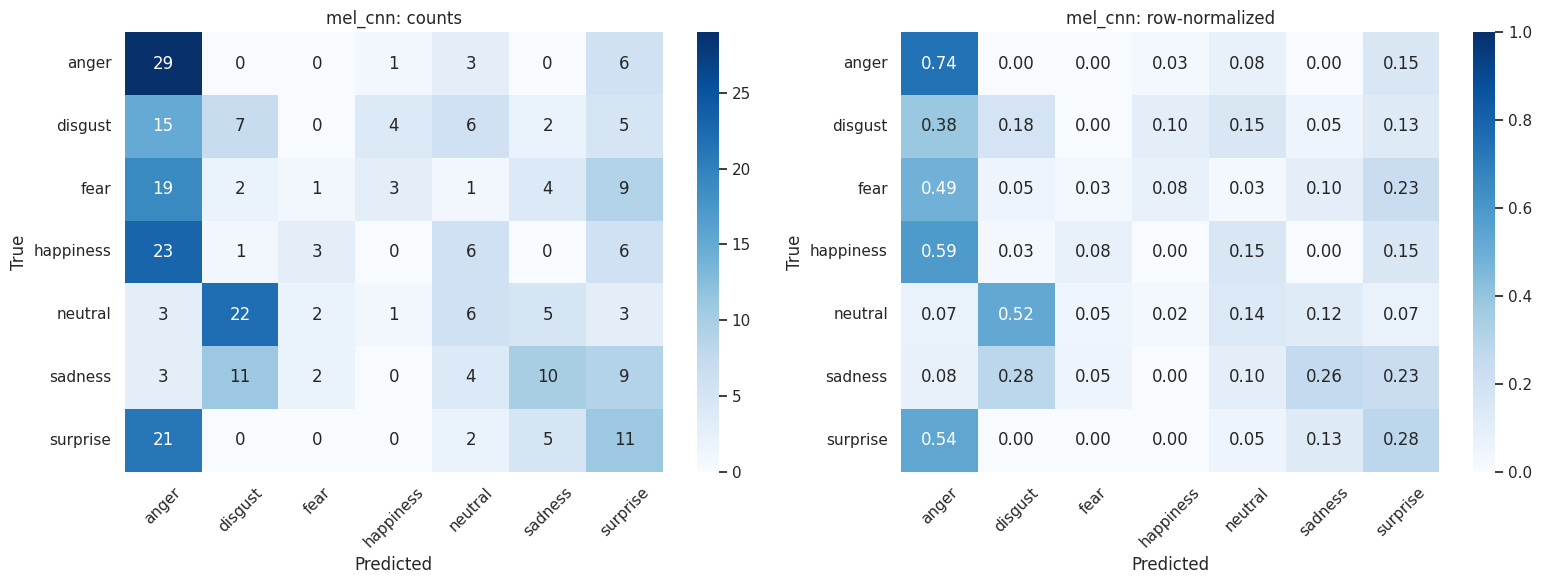


Training cnn_bilstm


/usr/lib/python3.13/multiprocessing/popen_fork.py:73: DeprecationWarning: This process (pid=1312) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6d5a040>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6d5a040>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: R

cnn_bilstm | epoch 001 | train F1 0.2317 | val F1 0.1677 | lr 3.00e-04


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: DeprecationWarning: This process (pid=1312) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6d5a040>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/

cnn_bilstm | epoch 002 | train F1 0.2514 | val F1 0.2019 | lr 3.00e-04


...

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: DeprecationWarning: This process (pid=1312) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6d5a040>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/

cnn_bilstm | epoch 039 | train F1 0.7346 | val F1 0.3913 | lr 9.37e-06


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: DeprecationWarning: This process (pid=1312) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6d5a040>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/

cnn_bilstm | epoch 040 | train F1 0.6926 | val F1 0.3905 | lr 9.37e-06
Early stopping cnn_bilstm at epoch 40.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: DeprecationWarning: This process (pid=1312) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6d5a040>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/

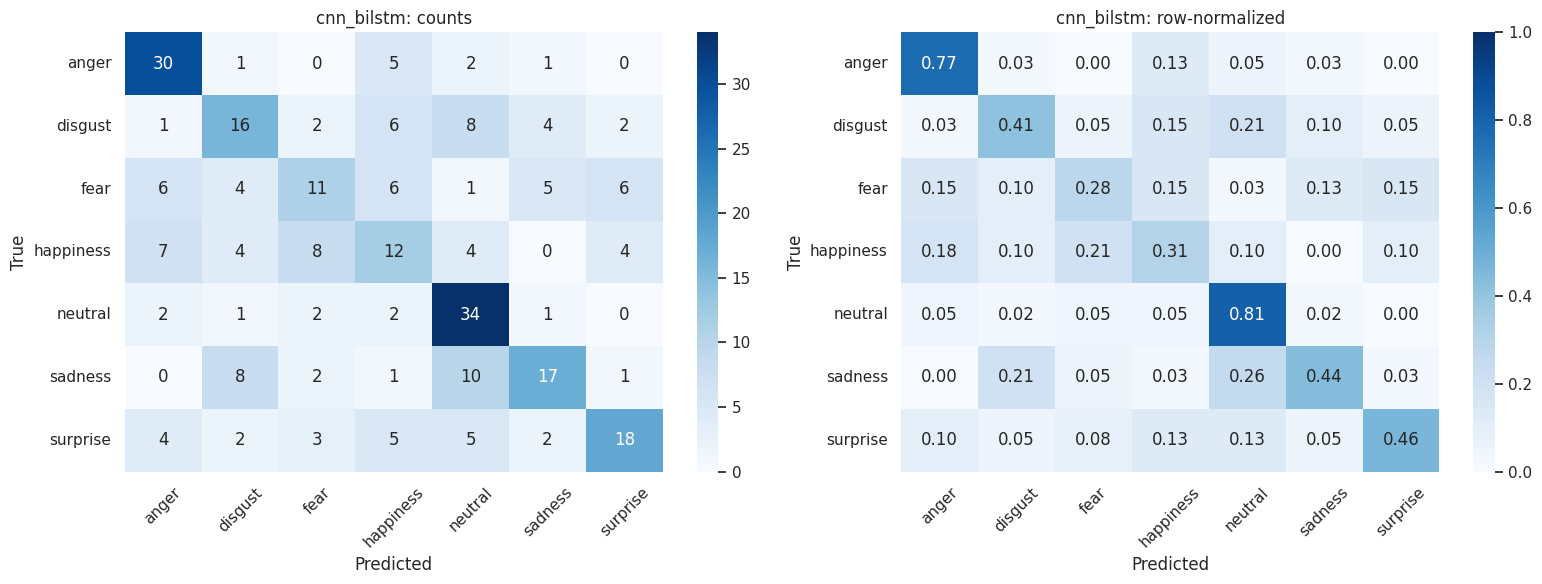


Training mel_transformer


/tmp/ipykernel_1312/2856066209.py:118: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=layers)
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: DeprecationWarning: This process (pid=1312) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6d5a040>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6d5a0

mel_transformer | epoch 001 | train F1 0.2276 | val F1 0.2120 | lr 3.00e-04


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: DeprecationWarning: This process (pid=1312) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6d5a040>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/

mel_transformer | epoch 002 | train F1 0.3134 | val F1 0.2344 | lr 3.00e-04


...

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: DeprecationWarning: This process (pid=1312) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6d5a040>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/

mel_transformer | epoch 018 | train F1 0.7466 | val F1 0.3252 | lr 7.50e-05


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: DeprecationWarning: This process (pid=1312) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6d5a040>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/

mel_transformer | epoch 019 | train F1 0.7653 | val F1 0.3210 | lr 7.50e-05
Early stopping mel_transformer at epoch 19.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: DeprecationWarning: This process (pid=1312) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6d5a040>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/

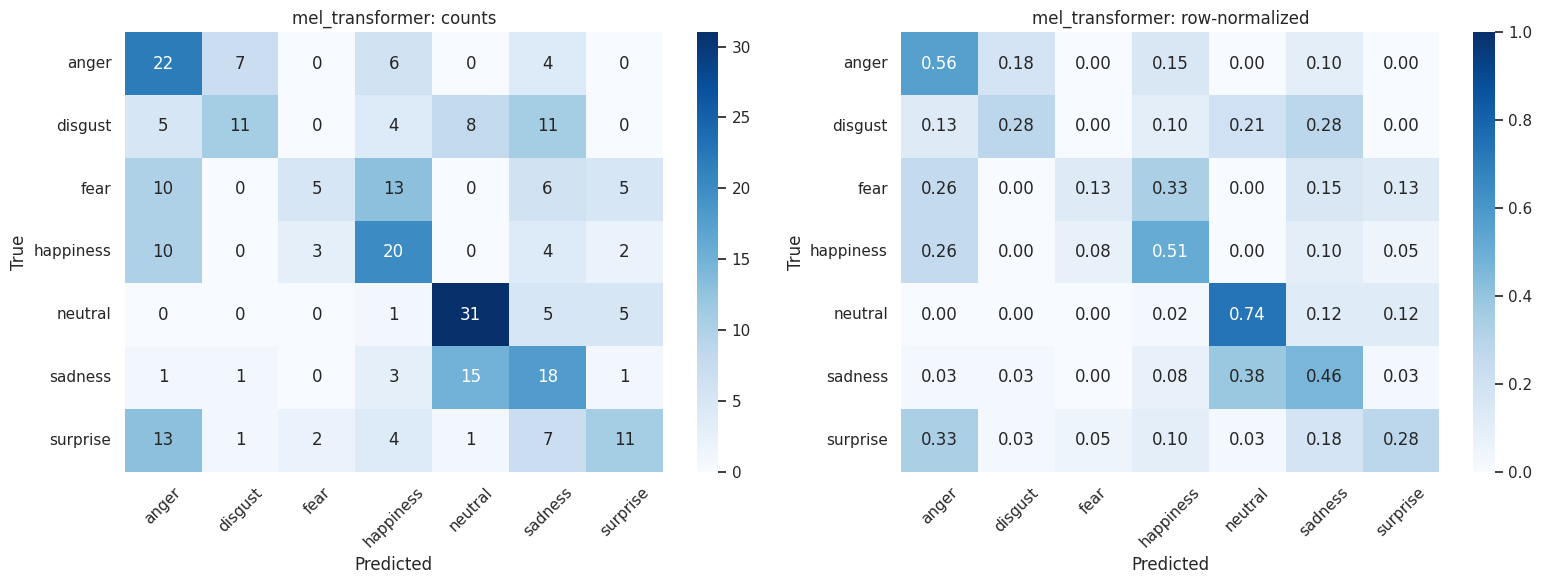

In [13]:
# Train and evaluate Mel-CNN, CNN-BiLSTM and Mel Transformer
for name in MEL_MODELS_TO_RUN:
    if name not in MEL_MODEL_BUILDERS:
        raise KeyError(f'Unknown mel model: {name}')

    print()
    print('=' * 70)
    print('Training', name)
    print('=' * 70)

    seed_everything(SEED)
    train_loader, val_loader, test_loader = make_mel_loaders()
    model = MEL_MODEL_BUILDERS[name]()

    model, best_val_f1, history = train_torch_model(
        name=name,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=MEL_EPOCHS,
        patience=MEL_PATIENCE,
        learning_rate=3e-4,
        weight_decay=1e-4,
    )

    val_logits, val_targets = collect_logits(model, val_loader)
    test_logits, test_targets = collect_logits(model, test_loader)
    assert np.array_equal(test_targets, y_test)

    temperature = fit_temperature(val_logits, val_targets)
    test_probs = calibrated_probabilities(test_logits, temperature)

    validation_scores[name] = best_val_f1
    prediction_store[name] = test_probs
    model_registry[name] = {
        'kind': 'mel',
        'model': model.cpu(),
        'temperature': temperature.cpu(),
    }

    row = metric_record(name, y_test, test_probs, test_groups)
    row['validation_macro_f1'] = best_val_f1
    row['temperature'] = float(temperature.temperature.item())
    np.save(
        ARTIFACT_ROOT / f'{name}_temperature.npy',
        np.array([row['temperature']], dtype=np.float32),
    )
    results.append(row)
    save_diagnostics(name, y_test, test_probs)

    del train_loader, val_loader, test_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


## Pretrained Wav2Vec2 model

The wrapper below fine-tunes Wav2Vec2. Padding masks are passed through to the backbone, only the final configured encoder layers are unfrozen, and model selection still uses validation macro F1.


In [14]:
# Wav2Vec2 datasets and model wrapper
class RawAudioDataset(Dataset):
    def __init__(self, indices, feature_extractor, training=False):
        self.indices = np.asarray(indices)
        self.feature_extractor = feature_extractor
        self.training = training

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        idx = int(self.indices[item])
        raw_audio = waveforms[idx, :valid_lengths[idx]].copy()
        if self.training and np.random.random() < 0.5:
            gain = np.random.uniform(0.80, 1.20)
            raw_audio = np.clip(raw_audio * gain, -1.0, 1.0)
        if self.training and np.random.random() < 0.35:
            signal_rms = np.sqrt(np.mean(raw_audio ** 2) + 1e-10)
            snr_db = np.random.uniform(20.0, 30.0)
            noise_rms = signal_rms / (10.0 ** (snr_db / 20.0))
            raw_audio = raw_audio + np.random.normal(
                0.0, noise_rms, size=raw_audio.shape
            ).astype(np.float32)
        raw_audio = np.clip(raw_audio, -1.0, 1.0).astype(np.float32)
        encoded = self.feature_extractor(
            raw_audio,
            sampling_rate=SAMPLE_RATE,
            max_length=N_SAMPLES,
            truncation=True,
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'input_values': encoded['input_values'].squeeze(0),
            'attention_mask': encoded['attention_mask'].squeeze(0),
            'labels': torch.tensor(labels[idx], dtype=torch.long),
        }

def make_ssl_loaders(feature_extractor):
    common = {
        'batch_size': SSL_BATCH_SIZE,
        'num_workers': 2,
        'pin_memory': DEVICE.type == 'cuda',
        'worker_init_fn': seed_worker,
    }
    train_loader = DataLoader(
        RawAudioDataset(train_idx, feature_extractor, training=True),
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
        **common,
    )
    val_loader = DataLoader(
        RawAudioDataset(val_idx, feature_extractor, training=False),
        shuffle=False,
        **common,
    )
    test_loader = DataLoader(
        RawAudioDataset(test_idx, feature_extractor, training=False),
        shuffle=False,
        **common,
    )
    return train_loader, val_loader, test_loader

class SSLEmotionClassifier(nn.Module):
    def __init__(
        self,
        pretrained_name,
        num_classes=NUM_CLASSES,
        unfreeze_last_n_layers=2,
    ):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(pretrained_name)

        for parameter in self.backbone.parameters():
            parameter.requires_grad = False

        encoder = getattr(self.backbone, 'encoder', None)
        layers = getattr(encoder, 'layers', None)
        if layers is not None and unfreeze_last_n_layers > 0:
            for layer in layers[-unfreeze_last_n_layers:]:
                for parameter in layer.parameters():
                    parameter.requires_grad = True

        hidden_size = int(self.backbone.config.hidden_size)
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(0.25),
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(256, num_classes),
        )

    def forward(self, input_values, attention_mask):
        output = self.backbone(
            input_values=input_values,
            attention_mask=attention_mask,
        )
        hidden = output.last_hidden_state

        if hasattr(self.backbone, '_get_feature_vector_attention_mask'):
            hidden_mask = self.backbone._get_feature_vector_attention_mask(
                hidden.shape[1],
                attention_mask,
            ).to(hidden.dtype)
            pooled = (
                hidden * hidden_mask.unsqueeze(-1)
            ).sum(dim=1) / hidden_mask.sum(dim=1, keepdim=True).clamp_min(1.0)
        else:
            pooled = hidden.mean(dim=1)

        return self.classifier(pooled)



Training ssl_wav2vec2 from facebook/wav2vec2-base


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.84k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  380MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

...

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: DeprecationWarning: This process (pid=1312) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6d5a040>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/

ssl_wav2vec2 | epoch 011 | train F1 0.7461 | val F1 0.5095 | lr 1.00e-05


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: DeprecationWarning: This process (pid=1312) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6d5a040>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/

ssl_wav2vec2 | epoch 012 | train F1 0.7337 | val F1 0.5180 | lr 1.00e-05
Early stopping ssl_wav2vec2 at epoch 12.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: DeprecationWarning: This process (pid=1312) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6d5a040>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/popen_fork.py:73: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79c2b6e8eac0>
  self.pid = os.fork()
/usr/lib/python3.13/multiprocessing/

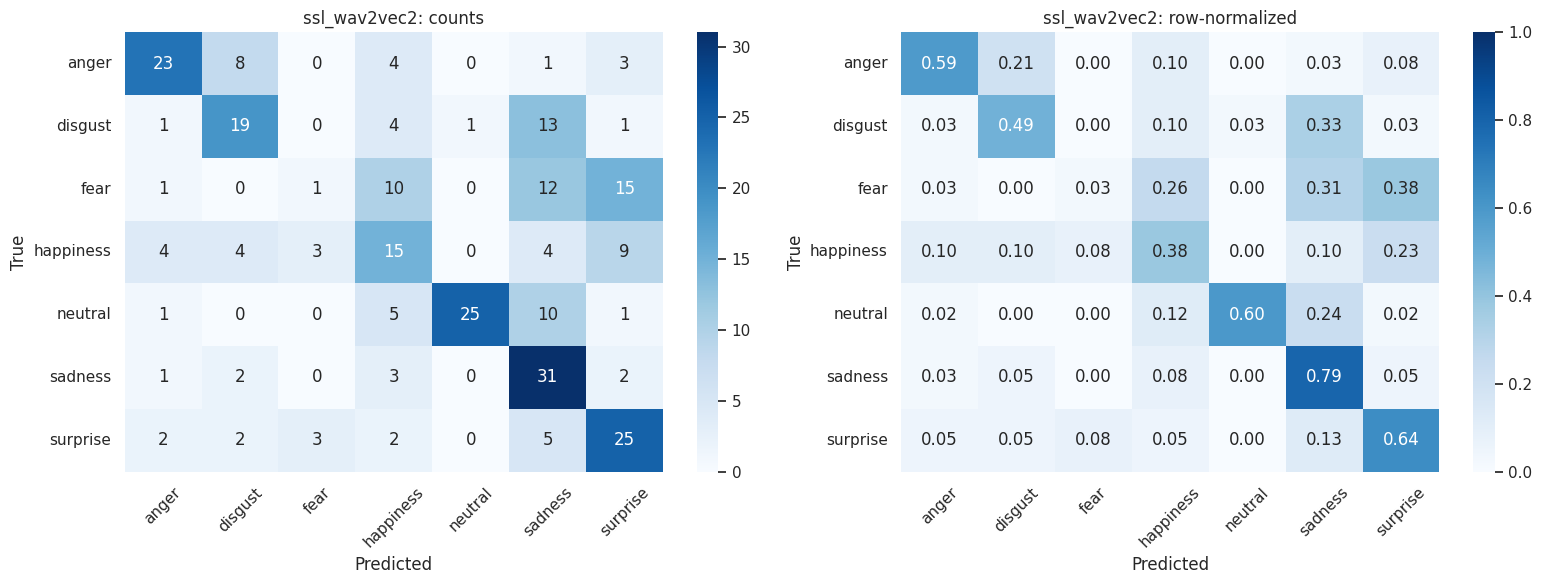

In [15]:
# Fine-tune Wav2Vec2 only
for short_name, pretrained_name in [('wav2vec2', WAV2VEC2_MODEL_NAME)]:
    model_name = f'ssl_{short_name}'

    print()
    print('=' * 70)
    print('Training', model_name, 'from', pretrained_name)
    print('=' * 70)

    seed_everything(SEED)
    feature_extractor = AutoFeatureExtractor.from_pretrained(pretrained_name)
    train_loader, val_loader, test_loader = make_ssl_loaders(feature_extractor)

    model = SSLEmotionClassifier(
        pretrained_name=pretrained_name,
        unfreeze_last_n_layers=SSL_UNFREEZE_LAST_N_LAYERS,
    )
    total_parameters = sum(p.numel() for p in model.parameters())
    trainable_parameters = sum(
        p.numel() for p in model.parameters() if p.requires_grad
    )
    print(
        f'Total parameters: {total_parameters:,}; '
        f'trainable: {trainable_parameters:,}'
    )

    model, best_val_f1, history = train_torch_model(
        name=model_name,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=SSL_EPOCHS,
        patience=SSL_PATIENCE,
        learning_rate=2e-5,
        weight_decay=0.01,
    )

    val_logits, val_targets = collect_logits(model, val_loader)
    test_logits, test_targets = collect_logits(model, test_loader)
    assert np.array_equal(test_targets, y_test)

    temperature = fit_temperature(val_logits, val_targets)
    test_probs = calibrated_probabilities(test_logits, temperature)

    validation_scores[model_name] = best_val_f1
    prediction_store[model_name] = test_probs
    model_registry[model_name] = {
        'kind': 'ssl',
        'model': model.cpu(),
        'temperature': temperature.cpu(),
        'feature_extractor': feature_extractor,
        'pretrained_name': pretrained_name,
    }

    row = metric_record(model_name, y_test, test_probs, test_groups)
    row['validation_macro_f1'] = best_val_f1
    row['temperature'] = float(temperature.temperature.item())
    np.save(
        ARTIFACT_ROOT / f'{model_name}_temperature.npy',
        np.array([row['temperature']], dtype=np.float32),
    )
    row['total_parameters'] = total_parameters
    row['trainable_parameters'] = trainable_parameters
    results.append(row)
    save_diagnostics(model_name, y_test, test_probs)

    del train_loader, val_loader, test_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


## Model comparison and error analysis

The table contains speaker-level bootstrap intervals. Because the test split contains relatively few independent speakers, these intervals may be wide; that is useful information rather than an error.

The deployment candidate is selected using validation macro F1. Test metrics are used only for final reporting and scientific comparison.


,model,validation_macro_f1,accuracy,accuracy_ci_low,accuracy_ci_high,macro_f1,macro_f1_ci_low,macro_f1_ci_high,macro_roc_auc_ovr,nll,brier,ece_15_bins
0,rbf_svm,0.3577,0.5072,0.4423,0.5725,0.5057,0.4350,0.5805,0.8287,1.4867,0.6745,0.0943
1,cnn_bilstm,0.4181,0.5000,0.4231,0.5913,0.4848,0.3992,0.5939,0.8317,1.4070,0.6556,0.0743
2,ssl_wav2vec2,0.5466,0.5036,0.3702,0.5874,0.4804,0.3009,0.5296,0.8618,1.3013,0.6395,0.0990
3,extra_trees,0.4002,0.4529,0.3846,0.5181,0.4314,0.3630,0.5188,0.8287,1.4513,0.6803,0.1168
4,mel_transformer,0.3343,0.4275,0.3514,0.5240,0.4047,0.2806,0.5150,0.7951,1.5568,0.7252,0.1119
5,mel_cnn,0.2121,0.2319,0.1860,0.3510,0.1891,0.1205,0.3069,0.7061,1.7691,0.8081,0.1113


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Deployment candidate selected by validation macro F1:
ssl_wav2vec2 0.546601327784714


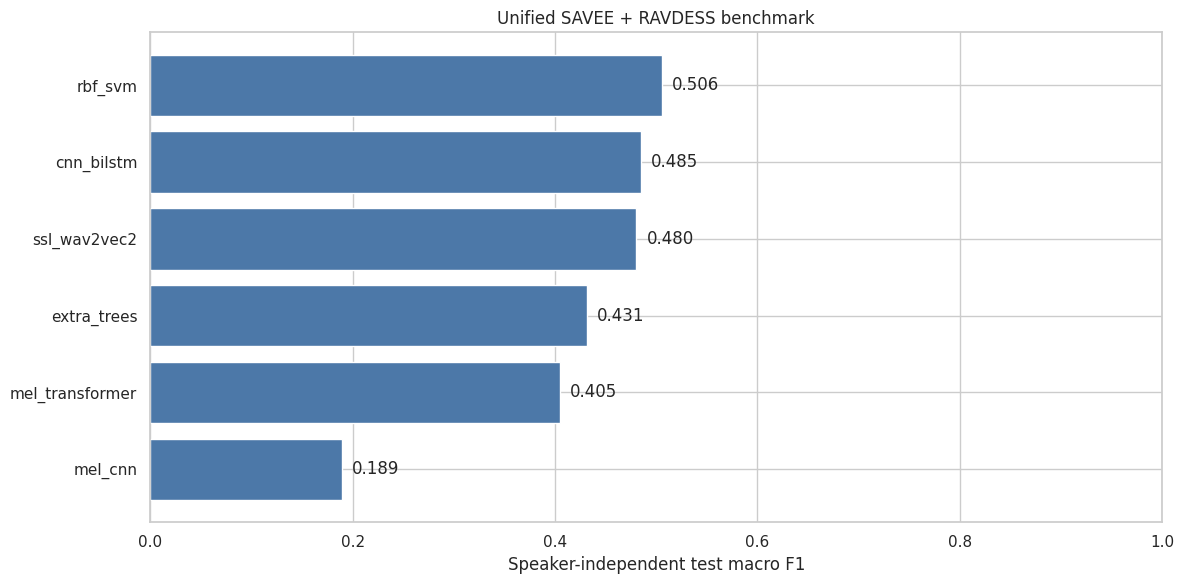

,model,dataset,samples,accuracy,macro_f1
6,cnn_bilstm,RAVDESS,156,0.5000,0.5122
7,cnn_bilstm,SAVEE,120,0.5000,0.3893
2,extra_trees,RAVDESS,156,0.4423,0.4469
3,extra_trees,SAVEE,120,0.4667,0.3493
4,mel_cnn,RAVDESS,156,0.2692,0.2258
5,mel_cnn,SAVEE,120,0.1833,0.1042
8,mel_transformer,RAVDESS,156,0.4423,0.4211
9,mel_transformer,SAVEE,120,0.4083,0.2782
0,rbf_svm,RAVDESS,156,0.5000,0.5043
1,rbf_svm,SAVEE,120,0.5167,0.4580


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [16]:
# Final benchmark table and corpus-specific analysis
results_df = pd.DataFrame(results).sort_values(
    ['macro_f1', 'accuracy'],
    ascending=False,
).reset_index(drop=True)

display_columns = [
    'model',
    'validation_macro_f1',
    'accuracy',
    'accuracy_ci_low',
    'accuracy_ci_high',
    'macro_f1',
    'macro_f1_ci_low',
    'macro_f1_ci_high',
    'macro_roc_auc_ovr',
    'nll',
    'brier',
    'ece_15_bins',
]
display(results_df[display_columns].round(4))
results_df.to_csv(ARTIFACT_ROOT / 'benchmark_results.csv', index=False)

# Select by validation score, never by test score.
deployment_model_name = max(validation_scores, key=validation_scores.get)
print('Deployment candidate selected by validation macro F1:')
print(deployment_model_name, validation_scores[deployment_model_name])

fig, ax = plt.subplots(figsize=(12, 6))
plot_frame = results_df.sort_values('macro_f1')
ax.barh(plot_frame.model, plot_frame.macro_f1, color='#4c78a8')
ax.set_xlabel('Speaker-independent test macro F1')
ax.set_xlim(0, 1)
ax.set_title('Unified SAVEE + RAVDESS benchmark')
for y_pos, value in enumerate(plot_frame.macro_f1):
    ax.text(value + 0.01, y_pos, f'{value:.3f}', va='center')
plt.tight_layout()
plt.savefig(
    ARTIFACT_ROOT / 'model_comparison_macro_f1.png',
    dpi=150,
    bbox_inches='tight',
)
plt.show()

breakdown_rows = []
test_metadata = manifest.loc[test_idx].reset_index(drop=True)

for model_name, probs in prediction_store.items():
    predictions = np.asarray(probs).argmax(axis=1)
    for corpus in sorted(test_metadata.dataset.unique()):
        mask = test_metadata.dataset.to_numpy() == corpus
        breakdown_rows.append({
            'model': model_name,
            'dataset': corpus,
            'samples': int(mask.sum()),
            'accuracy': accuracy_score(y_test[mask], predictions[mask]),
            'macro_f1': f1_score(
                y_test[mask],
                predictions[mask],
                average='macro',
                zero_division=0,
            ),
        })

breakdown_df = pd.DataFrame(breakdown_rows)
display(breakdown_df.sort_values(['model', 'dataset']).round(4))
breakdown_df.to_csv(
    ARTIFACT_ROOT / 'test_results_by_corpus.csv', index=False
)


In [17]:
# Theory-derived stress proxy
#
# This mapping is centralized and used once. It is not a clinical label.
def derived_stress_proxy(emotion_name, arousal_level):
    if emotion_name in {'anger', 'fear'}:
        return 'HIGH'
    if emotion_name in {'disgust', 'sadness'} and arousal_level == 'HIGH':
        return 'HIGH'
    return 'LOW'

best_probs = prediction_store[deployment_model_name]
best_predictions = best_probs.argmax(axis=1)
test_arousal = manifest.loc[test_idx, 'arousal_proxy'].to_numpy()
test_true_emotions = np.array([ID_TO_EMOTION[x] for x in y_test])
test_pred_emotions = np.array([ID_TO_EMOTION[x] for x in best_predictions])

reference_proxy = np.array([
    derived_stress_proxy(emotion, arousal)
    for emotion, arousal in zip(test_true_emotions, test_arousal)
])
predicted_proxy = np.array([
    derived_stress_proxy(emotion, arousal)
    for emotion, arousal in zip(test_pred_emotions, test_arousal)
])

reference_binary = (reference_proxy == 'HIGH').astype(int)
predicted_binary = (predicted_proxy == 'HIGH').astype(int)

proxy_agreement_accuracy = accuracy_score(reference_binary, predicted_binary)
proxy_agreement_macro_f1 = f1_score(
    reference_binary,
    predicted_binary,
    average='macro',
    zero_division=0,
)

print('Derived-stress rule agreement only')
print('Model:', deployment_model_name)
print('Agreement accuracy:', round(proxy_agreement_accuracy, 4))
print('Agreement macro F1:', round(proxy_agreement_macro_f1, 4))
print()
print(
    'Do not report these values as stress-detection accuracy. '
    'Both reference and prediction are generated by the same rule.'
)

proxy_output = test_metadata[[
    'sample_id', 'dataset', 'speaker', 'emotion', 'arousal_proxy'
]].copy()
proxy_output['predicted_emotion'] = test_pred_emotions
proxy_output['reference_stress_proxy'] = reference_proxy
proxy_output['predicted_stress_proxy'] = predicted_proxy
proxy_output.to_csv(
    ARTIFACT_ROOT / 'derived_stress_proxy_test_outputs.csv',
    index=False,
)


Derived-stress rule agreement only
Model: ssl_wav2vec2
Agreement accuracy: 0.75
Agreement macro F1: 0.7333

Do not report these values as stress-detection accuracy. Both reference and prediction are generated by the same rule.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [18]:
# Optional grouped cross-validation on train + validation speakers
#
# This inexpensive baseline measures split sensitivity without touching
# held-out test speakers.
if RUN_GROUPED_CV_BASELINE:
    development_idx = np.concatenate([train_idx, val_idx])
    X_development = engineered_features[development_idx]
    y_development = labels[development_idx]
    groups_development = manifest.loc[
        development_idx, 'speaker'
    ].to_numpy()

    grouped_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=SEED,
    )
    fold_scores = []

    base_estimator = clone(classical_models['rbf_svm'])

    for fold, (fit_local, score_local) in enumerate(
        grouped_cv.split(
            X_development,
            y_development,
            groups_development,
        ),
        start=1,
    ):
        estimator = clone(base_estimator)
        estimator.fit(
            X_development[fit_local],
            y_development[fit_local],
        )
        predictions = estimator.predict(X_development[score_local])
        fold_f1 = f1_score(
            y_development[score_local],
            predictions,
            average='macro',
            zero_division=0,
        )
        fold_scores.append(fold_f1)
        print(f'Fold {fold}: macro F1 = {fold_f1:.4f}')

    print(
        'Development grouped-CV macro F1:',
        f'{np.mean(fold_scores):.4f} +/- {np.std(fold_scores, ddof=1):.4f}',
    )


Fold 1: macro F1 = 0.3496


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Fold 2: macro F1 = 0.3626


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Fold 3: macro F1 = 0.4010


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Fold 4: macro F1 = 0.5064


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Fold 5: macro F1 = 0.4906
Development grouped-CV macro F1: 0.4220 +/- 0.0725


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Deployment-safe single-file inference

This function uses the same preprocessing statistics and real acoustic features as training. It does not contain credentials, launch a development server or replace learned inputs with zero vectors.


In [19]:
# Export metadata and provide one-file inference
with open(ARTIFACT_ROOT / 'deployment_selection.json', 'w') as handle:
    json.dump({
        'selected_by': 'highest validation macro F1',
        'model': deployment_model_name,
        'validation_macro_f1': validation_scores[deployment_model_name],
        'emotion_labels': EMOTIONS,
        'feature_fingerprint': FEATURE_FINGERPRINT,
        'arousal_note': 'training-statistics acoustic proxy; not ground truth',
        'stress_note': 'theory-derived rule output; not clinical stress',
    }, handle, indent=2)

def predict_audio_file(filepath, model_name=deployment_model_name):
    if model_name not in model_registry:
        raise KeyError(f'Model is not trained in this runtime: {model_name}')

    features = extract_one_file(str(filepath))
    registry = model_registry[model_name]

    if registry['kind'] == 'classical':
        probs = registry['model'].predict_proba(
            features['engineered'][None, :]
        )[0]

    elif registry['kind'] == 'mel':
        model = registry['model'].to(DEVICE).eval()
        mel = (
            features['log_mel'] - mel_mean[0]
        ) / mel_std[0]
        mel_tensor = torch.tensor(
            mel, dtype=torch.float32, device=DEVICE
        ).unsqueeze(0)
        with torch.no_grad():
            logits = model(mel=mel_tensor).cpu()
            probs = F.softmax(
                registry['temperature'](logits), dim=1
            ).numpy()[0]
        registry['model'] = model.cpu()

    elif registry['kind'] == 'ssl':
        extractor = registry['feature_extractor']
        raw = features['waveform'][:features['valid_length']]
        encoded = extractor(
            raw,
            sampling_rate=SAMPLE_RATE,
            max_length=N_SAMPLES,
            truncation=True,
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt',
        )
        model = registry['model'].to(DEVICE).eval()
        with torch.no_grad():
            logits = model(
                input_values=encoded['input_values'].to(DEVICE),
                attention_mask=encoded['attention_mask'].to(DEVICE),
            ).cpu()
            probs = F.softmax(
                registry['temperature'](logits), dim=1
            ).numpy()[0]
        registry['model'] = model.cpu()

    else:
        raise ValueError(f'Unsupported model kind: {registry["kind"]}')

    prediction_id = int(np.argmax(probs))
    emotion = ID_TO_EMOTION[prediction_id]

    pitch = float(features['prosody'][0])
    energy = float(features['prosody'][2])
    pitch_component = (
        (pitch - pitch_center) / pitch_scale
        if np.isfinite(pitch) else 0.0
    )
    energy_component = (
        (energy - energy_center) / energy_scale
        if np.isfinite(energy) else 0.0
    )
    score = 0.5 * pitch_component + 0.5 * energy_component
    arousal = 'HIGH' if score > arousal_threshold else 'LOW'
    stress = derived_stress_proxy(emotion, arousal)

    return {
        'model': model_name,
        'emotion': emotion,
        'emotion_id': prediction_id,
        'confidence': float(probs[prediction_id]),
        'emotion_probabilities': {
            ID_TO_EMOTION[i]: float(probs[i])
            for i in range(NUM_CLASSES)
        },
        'acoustic_arousal_proxy': arousal,
        'arousal_score': float(score),
        'derived_stress_proxy': stress,
        'disclaimer': (
            'Arousal and stress are rule-derived proxies, '
            'not clinical or independently labelled predictions.'
        ),
    }

print('Deployment candidate:', deployment_model_name)
print('Example:')
print("predict_audio_file('/content/example.wav')")


Deployment candidate: ssl_wav2vec2
Example:
predict_audio_file('/content/example.wav')


In [20]:
# Reproducibility and integrity report
integrity = {
    'manifest_samples': int(len(manifest)),
    'speakers_total': int(manifest.speaker.nunique()),
    'train_samples': int(len(train_idx)),
    'validation_samples': int(len(val_idx)),
    'test_samples': int(len(test_idx)),
    'train_speakers': sorted(train_speakers),
    'validation_speakers': sorted(val_speakers),
    'test_speakers': sorted(test_speakers),
    'speaker_overlap': {
        'train_validation': sorted(train_speakers & val_speakers),
        'train_test': sorted(train_speakers & test_speakers),
        'validation_test': sorted(val_speakers & test_speakers),
    },
    'feature_fingerprint': FEATURE_FINGERPRINT,
    'seed': SEED,
    'device': str(DEVICE),
    'versions': {
        'python': platform.python_version(),
        'torch': torch.__version__,
        'numpy': np.__version__,
        'pandas': pd.__version__,
        'librosa': librosa.__version__,
        'scikit_learn': sklearn.__version__,
    },
    'deployment_model_selected_by_validation': deployment_model_name,
    'stress_is_independently_labelled': False,
}

assert not integrity['speaker_overlap']['train_validation']
assert not integrity['speaker_overlap']['train_test']
assert not integrity['speaker_overlap']['validation_test']

with open(ARTIFACT_ROOT / 'integrity_report.json', 'w') as handle:
    json.dump(integrity, handle, indent=2)

print(json.dumps(integrity, indent=2))
print()
print('All artifacts saved to:', ARTIFACT_ROOT)


{
  "manifest_samples": 1727,
  "speakers_total": 28,
  "train_samples": 1176,
  "validation_samples": 275,
  "test_samples": 276,
  "train_speakers": [
    "RAVDESS_01",
    "RAVDESS_02",
    "RAVDESS_03",
    "RAVDESS_05",
    "RAVDESS_08",
    "RAVDESS_11",
    "RAVDESS_12",
    "RAVDESS_13",
    "RAVDESS_14",
    "RAVDESS_15",
    "RAVDESS_16",
    "RAVDESS_17",
    "RAVDESS_18",
    "RAVDESS_19",
    "RAVDESS_20",
    "RAVDESS_21",
    "RAVDESS_23",
    "RAVDESS_24",
    "SAVEE_DC",
    "SAVEE_KL"
  ],
  "validation_speakers": [
    "RAVDESS_04",
    "RAVDESS_06",
    "RAVDESS_07",
    "SAVEE_JK"
  ],
  "test_speakers": [
    "RAVDESS_09",
    "RAVDESS_10",
    "RAVDESS_22",
    "SAVEE_JE"
  ],
  "speaker_overlap": {
    "train_validation": [],
    "train_test": [],
    "validation_test": []
  },
  "feature_fingerprint": "00c0d4718cd5",
  "seed": 42,
  "device": "cuda",
  "versions": {
    "python": "3.13.15",
    "torch": "2.11.0+cu128",
    "numpy": "2.1.3",
    "pandas": "2.2.3

## How to report the results

Use wording such as:

> Models were evaluated using speaker-disjoint train, validation and test partitions of SAVEE and RAVDESS. Hyperparameters and probability calibration were selected using validation speakers only. The primary outcome was macro F1 on unseen test speakers, with speaker-level bootstrap confidence intervals.

For the stress component, use wording such as:

> The system produces a theory-derived stress proxy by combining predicted emotion with a training-calibrated acoustic arousal score. Because neither SAVEE nor RAVDESS provides independent stress ground truth, rule-agreement values are not interpreted as stress-detection accuracy.

Before a final dissertation submission, also run:

- All enabled models with at least three random seeds.
- Cross-corpus experiments: RAVDESS to SAVEE and SAVEE to RAVDESS.
- Evaluation on natural, non-acted speech or a genuinely stress-labelled dataset.
- Manual inspection of the consistently weak classes, especially happiness.
